<a href="https://colab.research.google.com/github/Mohamed-Hesham-Latif/ML-55-25005/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score

In [6]:
# Load the dataset from CSV file
df = pd.read_csv("data_banknote_authentication.csv")

# Display first few rows to understand structure
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [7]:
# Show information about dataset (data types, null values)
df.info()

# Show statistical summary of numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [8]:
# Check how many samples belong to each class
# This helps understand if data is balanced
df["Class"].value_counts()

,count
Class,
0,762
1,610


In [9]:
# Separate input features (X) and target variable (y)
X = df.drop("Class", axis=1)  # All columns except target
y = df["Class"]               # Target column

In [11]:
# Split the dataset into training and testing sets
# 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

In [14]:
# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=101)

# Define hyperparameters to tune using GridSearchCV
dt_param_grid = {
    "criterion": ["gini", "entropy"],     # Splitting criteria
    "max_depth": [None, 2, 3, 4, 5, 10],  # Tree depth
    "min_samples_split": [2, 5, 10],      # Minimum samples to split
    "max_leaf_nodes": [None, 2, 3, 5, 10] # Maximum leaf nodes
}

In [15]:
# Perform Grid Search to find best hyperparameters
grid_dt = GridSearchCV(
    dt_model,
    dt_param_grid,
    cv=5,               # 5-fold cross-validation
    scoring="accuracy", # Optimize for accuracy
    n_jobs=-1           # Use all CPU cores
)

# Train model
grid_dt.fit(X_train, y_train)

# Display best parameters found
print("Best Decision Tree Parameters:")
print(grid_dt.best_params_)

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': None, 'max_leaf_nodes': None, 'min_samples_split': 2}


In [16]:
# Use best model from GridSearch
best_dt = grid_dt.best_estimator_

# Make predictions on test data
dt_preds = best_dt.predict(X_test)

# Print accuracy score
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, dt_preds))

# Print detailed classification metrics
print("\nClassification Report:")
print(classification_report(y_test, dt_preds))

Decision Tree Accuracy:
0.9975728155339806

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       238
           1       0.99      1.00      1.00       174

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



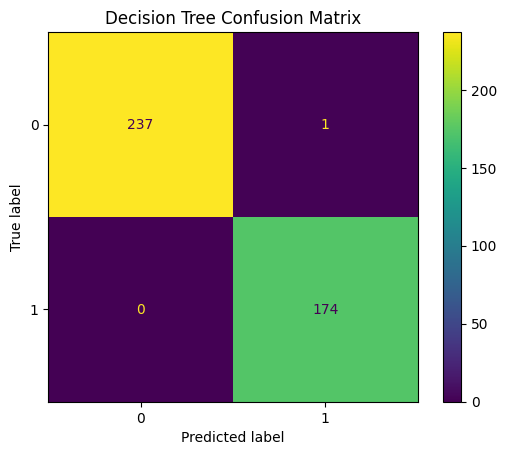

In [17]:
# Compute confusion matrix
cm_dt = confusion_matrix(y_test, dt_preds)

# Display confusion matrix visually
ConfusionMatrixDisplay(cm_dt).plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [18]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(random_state=101)

# Define hyperparameters for tuning
rf_param_grid = {
    "n_estimators": [50, 100, 200],   # Number of trees
    "max_depth": [None, 5, 10],       # Depth of trees
    "min_samples_split": [2, 5]       # Minimum samples to split
}

In [19]:
# Perform Grid Search for Random Forest
grid_rf = GridSearchCV(
    rf_model,
    rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train model
grid_rf.fit(X_train, y_train)

# Show best parameters
print("Best Random Forest Parameters:")
print(grid_rf.best_params_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [20]:
# Use best model
best_rf = grid_rf.best_estimator_

# Make predictions
rf_preds = best_rf.predict(X_test)

# Accuracy
print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_preds))

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy:
0.9902912621359223

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       238
           1       0.98      1.00      0.99       174

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



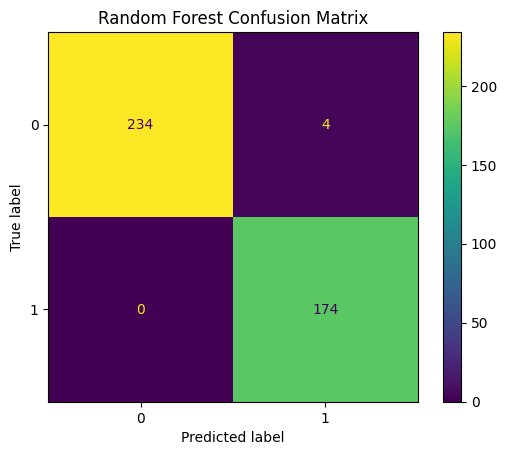

In [21]:
# Compute confusion matrix
cm_rf = confusion_matrix(y_test, rf_preds)

# Display it
ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [22]:
# Compare both model accuracies
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Decision Tree Accuracy: 0.9975728155339806
Random Forest Accuracy: 0.9902912621359223


Both models achieved very high accuracy on the banknote authentication dataset, indicating strong performance. However, the Decision Tree model slightly outperformed the Random Forest, achieving an accuracy of approximately 99.76% compared to 99.03% for the Random Forest. This suggests that, for this particular dataset, the Decision Tree was sufficient to capture the underlying patterns without the added complexity of an ensemble method. Therefore, the Decision Tree can be considered the better-performing model in this case.
